<a href="https://colab.research.google.com/github/Pranav77774/concept-and-technology-of-AI/blob/main/2501565_PranavManSingh_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Performance dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor # Added Neural Network
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# 1. Task 1: Data Pre-processing
# ==========================================
df = pd.read_csv('/content/drive/MyDrive/Student_Performance.csv')

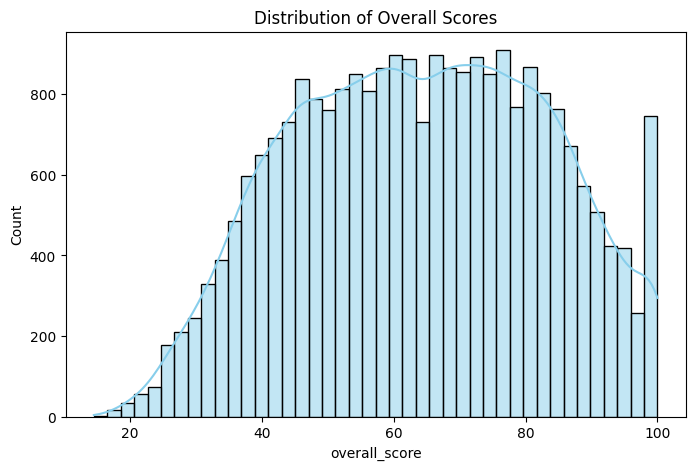

In [ ]:
# --- EDA Visualizations ---
# Histogram of Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['overall_score'], kde=True, color='skyblue')
plt.title('Distribution of Overall Scores')
plt.savefig('target_distribution.png')

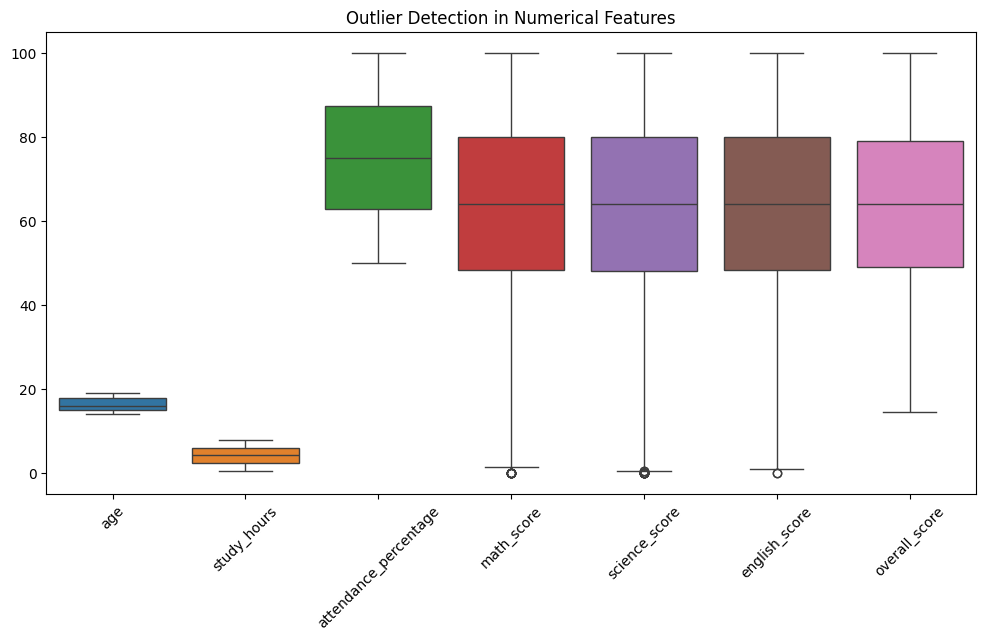

In [ ]:
# Outlier Detection Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=[np.number]).drop(columns=['student_id']))
plt.title('Outlier Detection in Numerical Features')
plt.xticks(rotation=45)
plt.savefig('outlier_boxplot.png')

In [ ]:
# Data Cleaning: Drop leakage columns and identifiers
# (Leakage columns math/science/english_score are dropped to make the model valid)
cols_to_drop = ['student_id', 'math_score', 'science_score', 'english_score', 'final_grade']
df_clean = df.drop(columns=cols_to_drop)

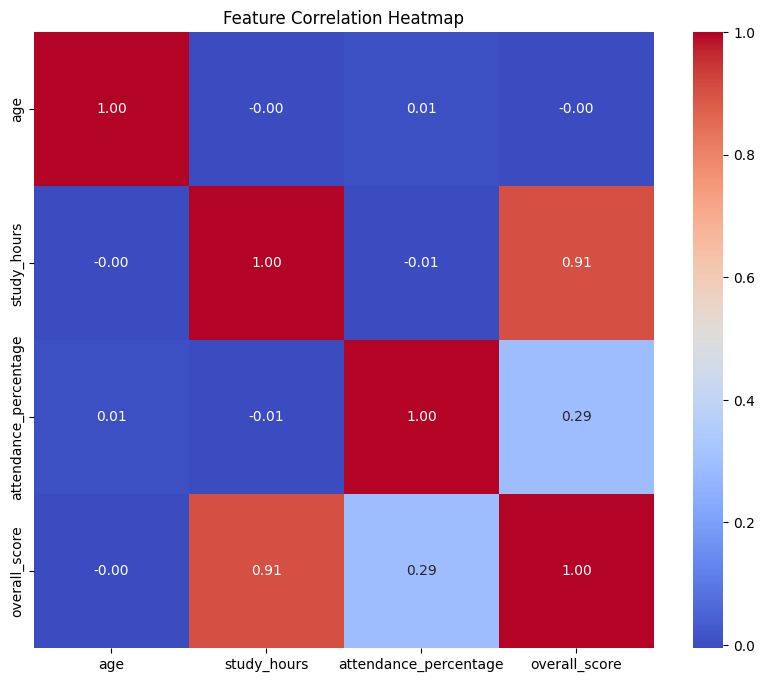

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

In [ ]:
# Encoding Categorical Variables
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

In [ ]:
# Outlier Clipping
def clip_outliers(data):
    num_cols = data.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        data[col] = data[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
clip_outliers(df_clean)

In [ ]:
# Split and Scale
X = df_clean.drop('overall_score', axis=1)
y = df_clean['overall_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [ ]:
# 2. Task 2: Linear Regression from Scratch
# ==========================================
class ScratchLinearRegression:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr, self.iterations = lr, iterations
    def fit(self, X, y):
        self.m, self.n = X.shape
        self.w, self.b = np.zeros(self.n), 0
        for _ in range(self.iterations):
            y_pred = np.dot(X, self.w) + self.b
            self.w -= self.lr * (1/self.m) * np.dot(X.T, (y_pred - y))
            self.b -= self.lr * (1/self.m) * np.sum(y_pred - y)
    def predict(self, X): return np.dot(X, self.w) + self.b

scratch_lr = ScratchLinearRegression()
scratch_lr.fit(X_train_std, y_train)

In [ ]:
# 3. Task 3 & 4: KNN, RF, and Tuning
# ==========================================
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_std, y_train)

# Random Forest Hyperparameter Tuning
param_grid = {'max_depth': [10, 20], 'min_samples_split': [2, 5]}
grid_rf = GridSearchCV(RandomForestRegressor(n_estimators=50), param_grid, cv=3)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_


In [ ]:
# Neural Network (MLP)
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train_std, y_train)

MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

In [ ]:
# 5. Task 5: Feature Selection
# ==========================================
# Get feature importances from the best RF model
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_5_features = importances.nlargest(5).index.tolist()
print(f"Selected Top 5 Features: {top_5_features}")

# Create final datasets based on selected features
X_train_fs = X_train[top_5_features]
X_test_fs = X_test[top_5_features]

# Retrain the best model on the selected features
final_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
final_model.fit(X_train_fs, y_train)

Selected Top 5 Features: ['study_hours', 'attendance_percentage', 'study_method', 'parent_education', 'age']


RandomForestRegressor(max_depth=20, random_state=42)

In [ ]:
# 4. Task 6: Evaluation & Comparison Diagrams
# ==========================================
models = {
    "Scratch LR": (scratch_lr, X_test_std),
    "KNN": (knn, X_test_std),
    "Tuned RF": (best_rf, X_test)
}

results = []
for name, (model, data) in models.items():
    preds = model.predict(data)
    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

res_df = pd.DataFrame(results)

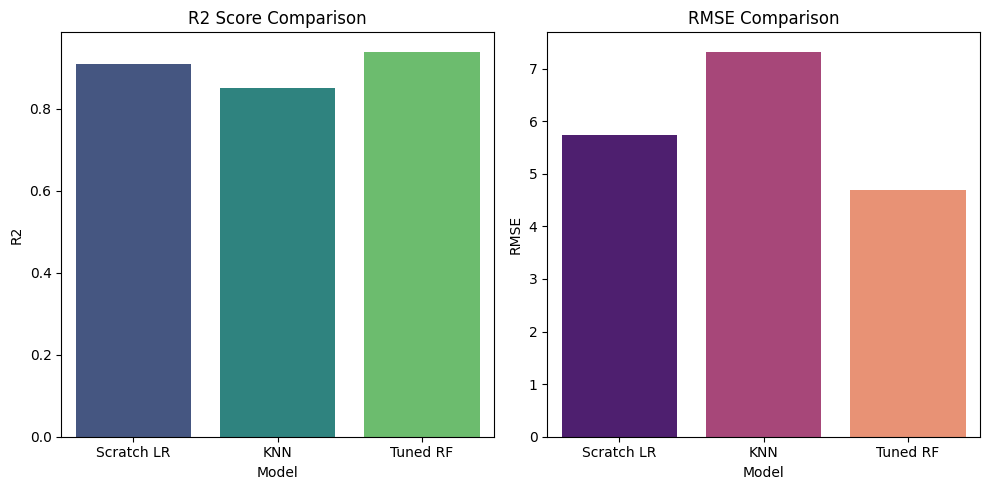

In [ ]:
# Plot Model Performance Comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='R2', data=res_df, palette='viridis')
plt.title('R2 Score Comparison')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='RMSE', data=res_df, palette='magma')
plt.title('RMSE Comparison')
plt.tight_layout()
plt.savefig('metrics_comparison.png')


--- Model Performance Summary ---
        Model      RMSE        R2
0  Scratch LR  5.742204  0.908696
1         KNN  7.325438  0.851407
2    Tuned RF  4.684630  0.939231


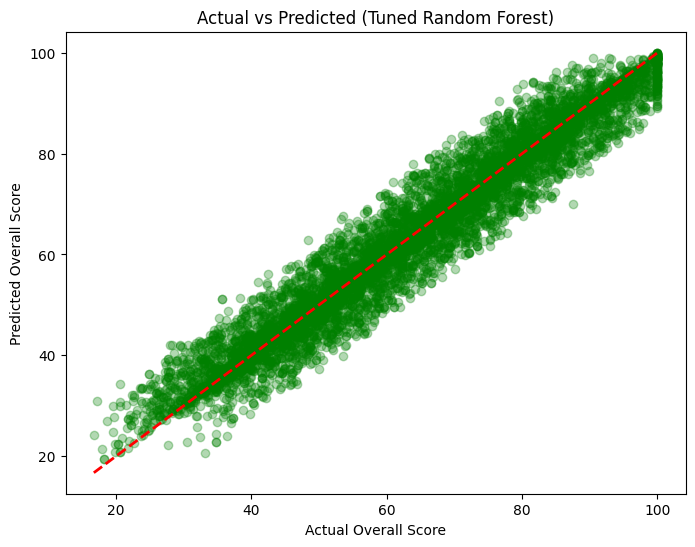

In [ ]:
# Best Model Plot: Actual vs Predicted
best_preds = best_rf.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted (Tuned Random Forest)')
plt.xlabel('Actual Overall Score')
plt.ylabel('Predicted Overall Score')
plt.savefig('actual_vs_predicted.png')

print("\n--- Model Performance Summary ---")
print(res_df)